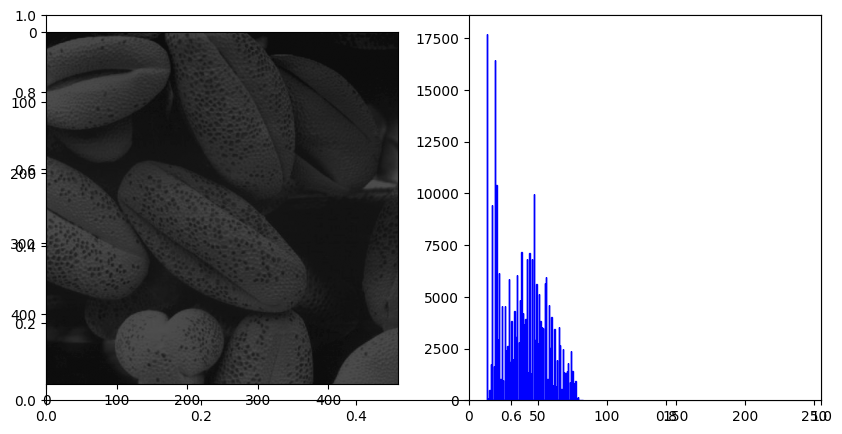

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

coffee = cv2.imread('assets/coffee.tif', 0)

plt.subplots(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(coffee, vmin=0, vmax=255, cmap='gray')

plt.subplot(1, 2, 2)
plt.hist(coffee.ravel(), bins=256, histtype='step', color='blue')
plt.xlim(0, 255)

plt.show()

Ukuran gambar: (500, 500)
Total piksel: 250000


,nilai_pixel,jumlah_pixel,pdf_probability,cdf,hasil_equalization
13,13,17718,0.070872,0.070872,18
14,14,96,0.000384,0.071256,18
15,15,506,0.002024,0.073280,19
16,16,1750,0.007000,0.080280,20
17,17,9441,0.037764,0.118044,30
...,...,...,...,...,...
78,78,116,0.000464,0.999336,255
79,79,150,0.000600,0.999936,255
80,80,5,0.000020,0.999956,255
81,81,10,0.000040,0.999996,255


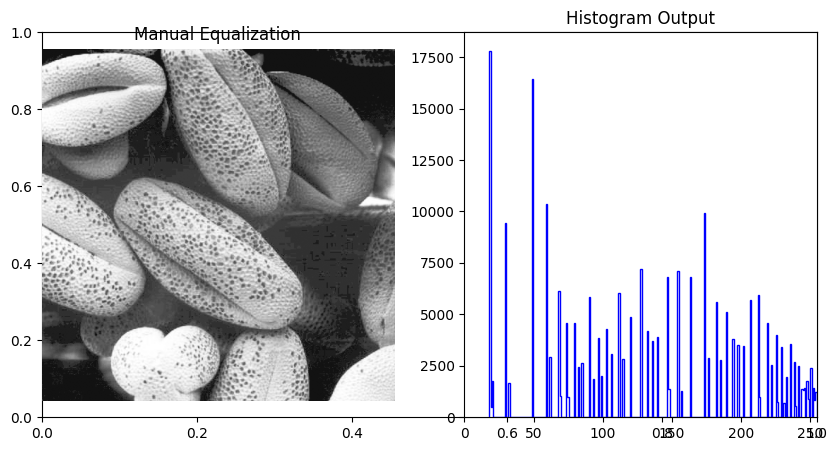

In [20]:
import pandas as pd
from matplotlib.figure import figaspect

# 1. Hitung Histogram
hist, bins = np.histogram(coffee.ravel(), bins=256, range=(0, 255))

# 2. Hitung total piksel 
total_pixels = coffee.size

print("Ukuran gambar:", coffee.shape)
print("Total piksel:", total_pixels)

# 3. Hitung PDF / Probability
pdf = hist / total_pixels

# 4. Hitung CDF
cdf = np.cumsum(pdf)

# 5. Normalisasi CDF ke rentang [0, 255]
cdf_normalized = np.round(cdf * 255).astype(np.uint8)

# 6. Mapping nilai piksel lama ke nilai baru
coffee_eq_manual = cdf_normalized[coffee]

# 7. Buat tabel per nilai piksel
df = pd.DataFrame({
    'nilai_pixel': np.arange(256),
    'jumlah_pixel': hist,
    'pdf_probability': pdf,
    'cdf': cdf,
    'hasil_equalization': cdf_normalized
})

# 8. Tampilkan hanya nilai piksel yang muncul di gambar
df_nonzero = df[df['jumlah_pixel'] > 0]

display(df_nonzero)

# 9. Tampilkan hasil
plt.subplots(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(coffee_eq_manual, vmin=0, vmax=255, cmap='gray')
plt.title('Manual Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(coffee_eq_manual.ravel(), bins=256, histtype='step', color='blue')
plt.xlim(0, 255)
plt.title('Histogram Output')

plt.show()